In [1]:
%load_ext autoreload
%autoreload 2

## 1. Imports

In [2]:
import os, sys
sys.path.append("..")

import torch
import wandb
from tqdm import tqdm

from src.light_gcot import LightGCOT
from src.distributions import StandardNormalSampler, SwissRollSampler

In [3]:
torch.set_default_tensor_type(torch.DoubleTensor)

/Users/michael/miniconda3/envs/light-gcot/lib/python3.12/site-packages/torch/__init__.py:749: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1718580122180/work/torch/csrc/tensor/python_tensor.cpp:433.)
  _C._set_default_tensor_type(t)


## 2. Config

In [11]:
X_DIM = 2
Y_DIM = 2
assert X_DIM > 1
# assert Y_DIM > 1

OUTPUT_SEED = 42

N_POTENTIALS = 500
M_POTENTIALS = 10
INIT_BY_SAMPLES = False
A_DIAGONAL_INIT = 0.1
IS_B_DIAGONAL = True

BATCH_SIZE = 128
SAMPLING_BATCH_SIZE = 128

EPSILON = 0.002

D_LR = 3e-4 # 1e-3 for eps 0.1, 0.01 and 3e-4 for eps 0.002
D_GRADIENT_MAX_NORM = float('inf')

PLOT_EVERY = 500
MAX_STEPS = 20000
CONTINUE = -1

In [12]:
torch.manual_seed(OUTPUT_SEED)

In [22]:
EXP_NAME = f'LightGCOT_Swiss_Roll_EPSILON_{EPSILON}_N_{N_POTENTIALS}_M_{M_POTENTIALS}_with_cost'
OUTPUT_PATH = '../checkpoints/{}'.format(EXP_NAME)

config = dict(
    X_DIM=X_DIM,
    Y_DIM=Y_DIM,
    D_LR=D_LR,
    BATCH_SIZE=BATCH_SIZE,
    EPSILON=EPSILON,
    D_GRADIENT_MAX_NORM=D_GRADIENT_MAX_NORM,
    N_POTENTIALS=N_POTENTIALS,
    M_POTENTIALS=M_POTENTIALS,
    INIT_BY_SAMPLES=INIT_BY_SAMPLES,
    A_DIAGONAL_INIT=A_DIAGONAL_INIT,
    IS_B_DIAGONAL=IS_B_DIAGONAL,
)

if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)

## 3. Create samplers

In [23]:
X_sampler = StandardNormalSampler(dim=X_DIM, device="cpu")
Y_sampler = SwissRollSampler(dim=Y_DIM, device="cpu")

## 4. Model initialization

In [34]:
D = LightGCOT(
    x_dim=X_DIM,
    y_dim=Y_DIM,
    n_potentials=N_POTENTIALS,
    m_potentials=M_POTENTIALS,
    epsilon=EPSILON,
    sampling_batch_size=SAMPLING_BATCH_SIZE,
    A_diagonal_init=A_DIAGONAL_INIT,
    is_B_diagonal=IS_B_DIAGONAL,
)

if INIT_BY_SAMPLES:
    D.init_a_by_samples(Y_sampler.sample(N_POTENTIALS))

D_opt = torch.optim.Adam(D.parameters(), lr=D_LR)

if CONTINUE > -1:
    D_opt.load_state_dict(torch.load(os.path.join(OUTPUT_PATH, f"D_opt_{OUTPUT_SEED}_{CONTINUE}.pt")))

In [35]:
for step in range(CONTINUE + 1, MAX_STEPS):
    # training cycle
    D_opt.zero_grad()

    X, Y = X_sampler.sample(BATCH_SIZE), Y_sampler.sample(BATCH_SIZE)

    b_m = D.compute_b_m(X)  # [bs x M x y_dim]
    B_m = D.compute_B_m(X)  # [bs x M x y_dim]
    log_v_m = D.compute_log_v_m(X)  # [bs x M]

    f_c = D.compute_dual_potential(b_m, B_m, log_v_m)
    f = D.compute_primal_potential(Y)
    c = D.compute_cost(Y, b_m, B_m, log_v_m)

    D_loss = (c - f_c - f).mean()
    D_loss.backward()
    D_gradient_norm = torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=D_GRADIENT_MAX_NORM)
    D_opt.step()

    print(
        f"{step}: D gradient norm: {D_gradient_norm.item():.4f} D_loss: {D_loss.item():.4f} lam_min(A): {torch.min(D.A_diagonal_matrix)}, lam_min(B): {torch.min(D.B_m_matrix)}"
    )

0: D gradient norm: 0.1544 D_loss: 0.2495 lam_min(A): 0.744096666362859, lam_min(B): 0.06744111616514495
1: D gradient norm: 0.1514 D_loss: 0.3034 lam_min(A): 0.7437966606844773, lam_min(B): 0.11184503176097459
2: D gradient norm: 0.1851 D_loss: 0.2665 lam_min(A): 0.7434976769378369, lam_min(B): 0.08337000712708188
3: D gradient norm: 0.2132 D_loss: 0.3333 lam_min(A): 0.743196968684615, lam_min(B): 0.050865159687357504
4: D gradient norm: 0.1478 D_loss: 0.2946 lam_min(A): 0.7428963981715847, lam_min(B): 0.05737232384534466
5: D gradient norm: 0.1311 D_loss: 0.2359 lam_min(A): 0.7426394245437259, lam_min(B): 0.11179265265405508
6: D gradient norm: 0.1878 D_loss: 0.2889 lam_min(A): 0.7423653369695313, lam_min(B): 0.09861859310045316
7: D gradient norm: 0.1768 D_loss: 0.3005 lam_min(A): 0.7420737445037232, lam_min(B): 0.08606760133284777
8: D gradient norm: 0.1760 D_loss: 0.3123 lam_min(A): 0.7417768212605017, lam_min(B): 0.05209521601297503
9: D gradient norm: 0.1484 D_loss: 0.2402 lam_m

ValueError: Expected parameter logits (Tensor of shape (128, 10)) of distribution Categorical(logits: torch.Size([128, 10])) to satisfy the constraint IndependentConstraint(Real(), 1), but found invalid values:
tensor([[nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        ...,
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan]], grad_fn=<SubBackward0>)

In [17]:
torch.save(D.state_dict(), os.path.join(OUTPUT_PATH, f"D.pt"))
torch.save(D_opt.state_dict(), os.path.join(OUTPUT_PATH, f"D_opt.pt"))

In [21]:
from matplotlib import pyplot as plt

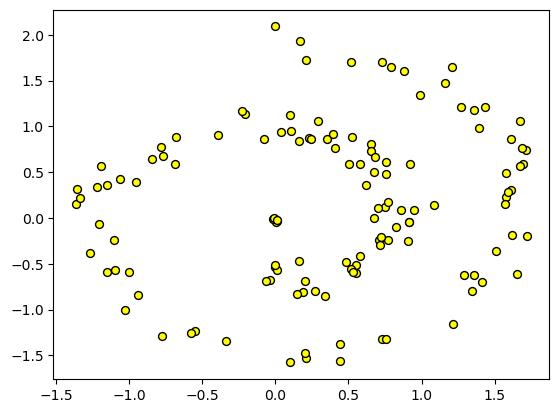

In [22]:
y_pred = D(X)
    
plt.scatter(y_pred[:, 0], y_pred[:, 1], 
            c="yellow", s=32, edgecolors="black", label = "Fitted distribution", zorder=1)

In [23]:
D.A_diagonal_matrix[:, 1].shape

torch.Size([500])

(array([354.,  81.,  39.,   0.,   0.,   0.,   0.,   0.,   0.,  26.]),
 array([ 0.41733428,  1.39054073,  2.36374717,  3.33695361,  4.31016006,
         5.2833665 ,  6.25657294,  7.22977938,  8.20298583,  9.17619227,
        10.14939871]),
 <BarContainer object of 10 artists>)

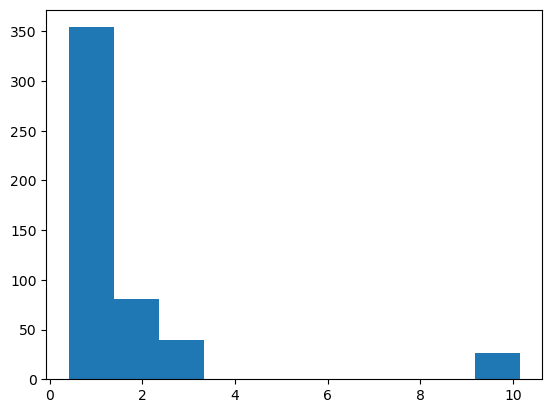

In [24]:
plt.hist(D.A_diagonal_matrix[:, 0].detach().numpy())

(array([ 10.,   6.,   4.,  40., 165., 166.,  84.,   7.,   7.,  11.]),
 array([-5.32135902, -4.2670573 , -3.21275559, -2.15845388, -1.10415217,
        -0.04985045,  1.00445126,  2.05875297,  3.11305469,  4.1673564 ,
         5.22165811]),
 <BarContainer object of 10 artists>)

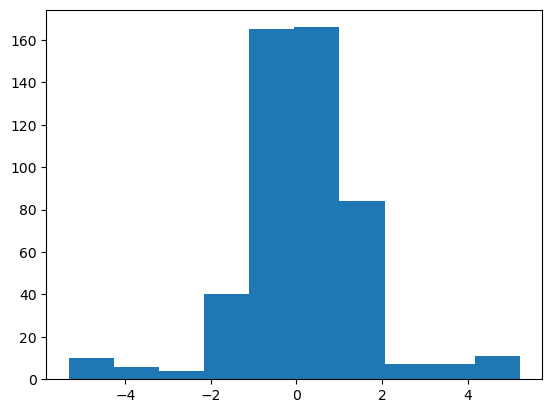

In [25]:
plt.hist(D.a[:, 1].detach().numpy())

(array([  5.,   7.,   1.,  69., 133., 223.,  45.,   4.,   4.,   9.]),
 array([-5.44495019e+00, -4.35614655e+00, -3.26734292e+00, -2.17853929e+00,
        -1.08973565e+00, -9.32022207e-04,  1.08787161e+00,  2.17667524e+00,
         3.26547888e+00,  4.35428251e+00,  5.44308614e+00]),
 <BarContainer object of 10 artists>)

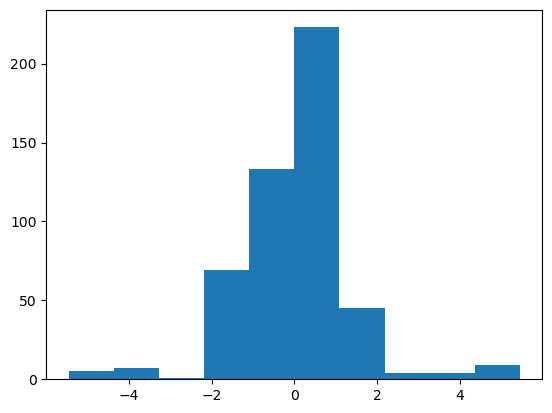

In [26]:
plt.hist(D.a[:, 0].detach().numpy())

## 5. Model training

In [9]:
wandb.init(name=EXP_NAME, config=config)

for step in tqdm(range(CONTINUE + 1, MAX_STEPS)):
    # training cycle
    D_opt.zero_grad()

    X, Y = X_sampler.sample(BATCH_SIZE), Y_sampler.sample(BATCH_SIZE)

    f_c = D.compute_dual_potential(X)
    f = D.compute_primal_potential(Y)

    D_loss = -(f_c + f).mean()
    D_loss.backward()
    D_gradient_norm = torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=D_GRADIENT_MAX_NORM)
    D_opt.step()

    wandb.log({f"D gradient norm": D_gradient_norm.item()}, step=step)
    wandb.log({f"D_loss": D_loss.item()}, step=step)

torch.save(D.state_dict(), os.path.join(OUTPUT_PATH, f"D.pt"))
torch.save(D_opt.state_dict(), os.path.join(OUTPUT_PATH, f"D_opt.pt"))

wandb.finish()

wandb: WARNING Source type is set to 'repo' but some required information is missing from the environment. A job will not be created from this run. See https://docs.wandb.ai/guides/launch/create-job


D gradient norm,nan
D_loss,nan


Problem at: /Users/michael/miniconda3/envs/light-sb/lib/python3.12/site-packages/wandb/sdk/wandb_init.py 854 getcaller


KeyboardInterrupt: 